In [1]:
from instruments.spectrometer import Spectrometer
from instruments.spectrometer.utils import autoexposure

from instruments.monochromator.mono import MonochromatorControl

import matplotlib.pyplot as plt

In [2]:
sp = Spectrometer(serial="SR600410")

Connected to OCEANSR6 (SN SR600410)


In [3]:
mono = MonochromatorControl(port='COM4')
mono.initialize_arduino()
mono.home_motor()
mono.select_grating_mode(mode="VIS Grating")
mono.set_wavelength(550.0)

Connected to COM4; you can now initialize the Monochromator.
INFO: monochromator initialized; send `home` to start
INFO: homing
ADC: 293
OK: homed
OK: mode VIS
INFO: moving 550.00
OK: wavelength 550.00


In [10]:
mono.set_wavelength(550.0)

INFO: moving 550.00
OK: wavelength 550.00


In [4]:
autoexposure(sp, target=0.5)

27672

In [6]:
mono.goto_lamp_baseline()

INFO: moving_steps 338
OK: moved 338


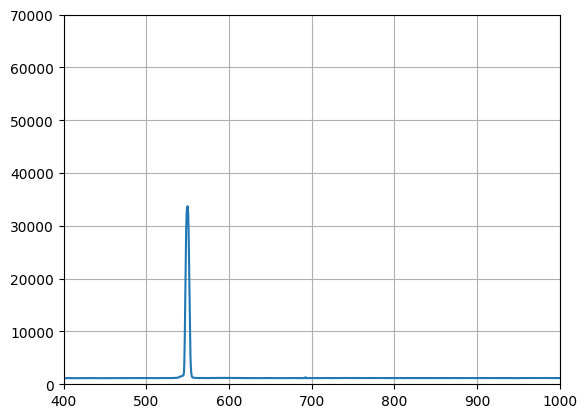

In [11]:
wl, counts = sp.snapshot()
plt.plot(wl, counts)
plt.xlim([400, 1000])
plt.ylim([0, 70000])
#plt.vlines(550, 0, 35000, 'r')
plt.grid()